In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# 1. CLASIFICACIÓN CLÍNICA ADAPTADA A TU DATASET
def clasificar_enfoque(med):
    med_lower = str(med).lower().strip()
    # Medicamentos que van a la causa directa (Infecciones/Bacterias)
    if any(antibi in med_lower for antibi in ['amoxicillin', 'penicillin', 'cefazolina', 'clindamicina', 'antibiotic']):
        return 'Enfoque Causal\n(Trata la Infección)'
    else:
        # Fármacos sintomáticos, analgésicos o de soporte sistémico (como Amlodipine/Ibuprofen)
        return 'Enfoque Sintomático / Soporte\n(Trata Síntomas)'

df['Enfoque_Clinico'] = df['Recommended_Medication'].apply(clasificar_enfoque)

In [16]:
# 2. MAPEÓ DE ENTRADAS CON TUS DATOS REALES (Effective y Yes)
# Convertimos la efectividad a un número (1 si fue efectivo, 0 si no)
df['Eficacia_Binaria'] = df['Treatment_Effectiveness'].apply(lambda x: 1 if str(x).strip().lower() == 'effective' else 0)

# Convertimos las reacciones adversas a un número real (1 si es 'yes', 0 si es 'no')
df['Reaccion_Binaria'] = df['Adverse_Reactions'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

# 3. AGRUPACIÓN CLÍNICA PARA COMPARAR LAS DOS ESTRATEGIAS
analisis_estrategia = df.groupby('Enfoque_Clinico').agg(
    Eficacia_Promedio=('Eficacia_Binaria', lambda x: x.mean() * 100),
    Riesgo_Adverso=('Reaccion_Binaria', lambda x: x.mean() * 100)
).reset_index()

C:\Users\aegon\AppData\Local\Temp\ipykernel_23436\595422610.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(


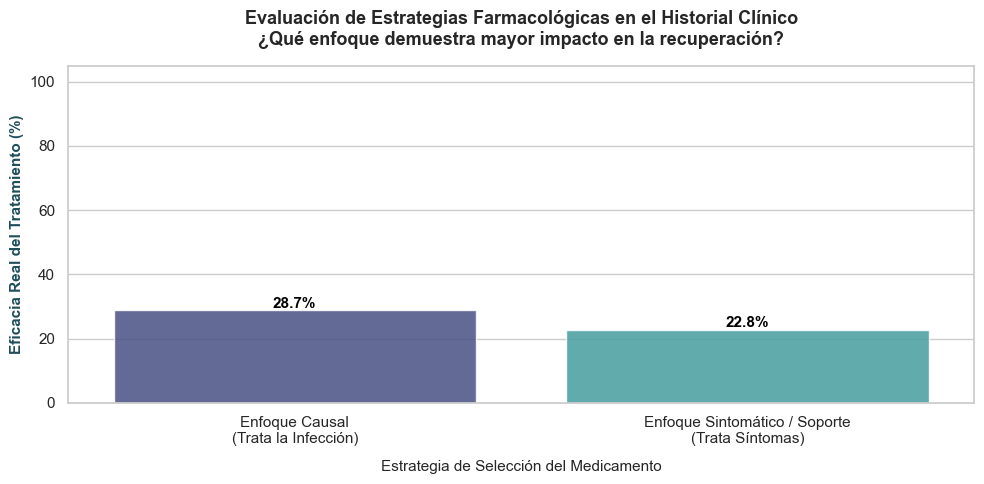

In [20]:
# 4. GENERAR GRÁFICA DE ALTA CALIDAD PARA EL PROFESOR GOTOY
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 5))

# Dibujar las barras de Eficacia Clínica (Cambiamos 'Teal' por 'mako')
barras = sns.barplot(
    data=analisis_estrategia, 
    x='Enfoque_Clinico', 
    y='Eficacia_Promedio', 
    ax=ax1, 
    palette='mako',
    alpha=0.85
)

# Configuración estética del gráfico
ax1.set_title('Evaluación de Estrategias Farmacológicas en el Historial Clínico\n¿Qué enfoque demuestra mayor impacto en la recuperación?', fontsize=13, pad=15, fontweight='bold')
ax1.set_xlabel('Estrategia de Selección del Medicamento', fontsize=11, labelpad=10)
ax1.set_ylabel('Eficacia Real del Tratamiento (%)', fontsize=11, color='#1f4e5b', fontweight='bold')
ax1.set_ylim(0, 105)

# Agregar las etiquetas de porcentaje exacto sobre cada barra
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 2),
                ha='center', va='center', color='black', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# 5. IMPRIMIR REPORTE DE CONCLUSIÓN EN LA CONSOLA
print("\n" + "="*60)
print("             CONCLUSIÓN MÉDICA DEL DATASET")
print("="*60)
for _, fila in analisis_estrategia.iterrows():
    print(f"📌 {fila['Enfoque_Clinico'].replace('\n', ' ')}:")
    print(f"   -> Eficacia resolutiva: {fila['Eficacia_Promedio']:.1f}%")
    print(f"   -> Incidencia de reacciones adversas: {fila['Riesgo_Adverso']:.1f}%\n")
print("="*60)

--- DESEMPEÑO DEL MODELO BASELINE ---
Exactitud Global (Accuracy): 0.47

Reporte de Clasificación Clínica:
              precision    recall  f1-score   support

           0       0.46      0.40      0.43        99
           1       0.48      0.53      0.50       101

    accuracy                           0.47       200
   macro avg       0.47      0.47      0.47       200
weighted avg       0.47      0.47      0.47       200

